<a href="https://colab.research.google.com/github/mc4830913-max/python/blob/main/models/randomforestalgorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest Algorithm**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns

In [18]:
df=sns.load_dataset("iris")

In [19]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [20]:
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [21]:







df["species"]=df["species"].replace({"setosa":0,
"versicolor":1,
"virginica":2
                                     })

/tmp/ipykernel_652/3761909647.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["species"]=df["species"].replace({"setosa":0,


In [22]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
63,6.1,2.9,4.7,1.4,1
35,5.0,3.2,1.2,0.2,0
96,5.7,2.9,4.2,1.3,1
112,6.8,3.0,5.5,2.1,2
14,5.8,4.0,1.2,0.2,0
79,5.7,2.6,3.5,1.0,1
107,7.3,2.9,6.3,1.8,2
134,6.1,2.6,5.6,1.4,2
61,5.9,3.0,4.2,1.5,1
81,5.5,2.4,3.7,1.0,1


In [23]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [24]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,int64


In [25]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [26]:
df.corr()

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.117570,0.871754,0.817941,0.782561
sepal_width,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal_length,0.871754,-0.428440,1.000000,0.962865,0.949035
petal_width,0.817941,-0.366126,0.962865,1.000000,0.956547
species,0.782561,-0.426658,0.949035,0.956547,1.000000


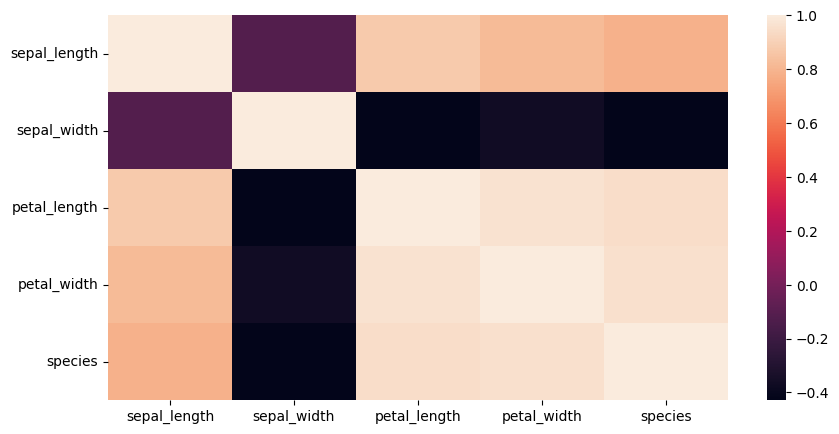

In [27]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr())
plt.show()

In [28]:
x=df.drop(columns="species",axis=1)
y=df["species"]

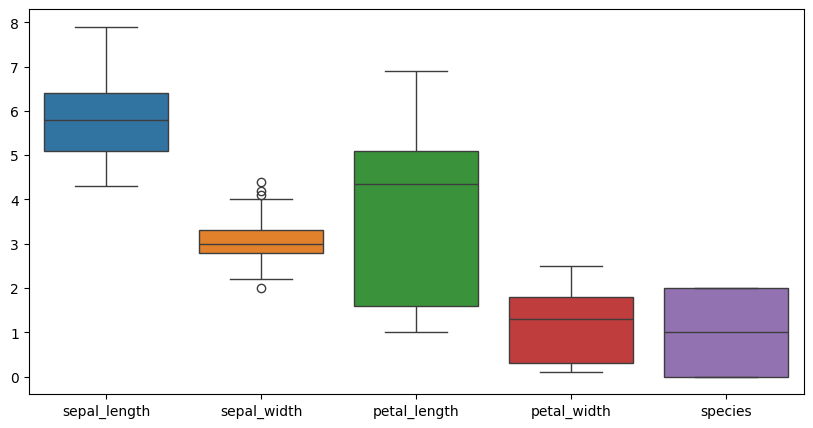

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.savefig("boxplot.png")
plt.show()

In [ ]:
fro

In [35]:
from sklearn.preprocessing import StandardScaler
model=StandardScaler()
x_scaled=model.fit_transform(x)

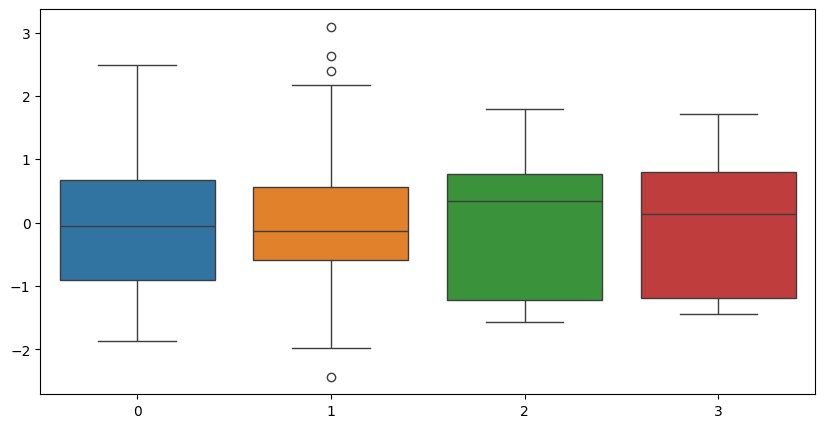

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(data=x_scaled)
plt.savefig("boxplot.png")
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=42)

In [42]:
x_train.shape

(105, 4)

In [43]:
x_test.shape

(45, 4)

In [50]:
from sklearn.ensemble import RandomForestClassifier
model_1=RandomForestClassifier(n_estimators=100,random_state=42)
rf=model_1.fit(x_train,y_train)
rf

RandomForestClassifier(random_state=42)

In [58]:
y_train.head()


,species
81,1
133,2
137,2
75,1
109,2


In [63]:
y_pred=rf.predict(x_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [66]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



**by gridsearchcv**

In [67]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}


In [68]:
Grid_search=GridSearchCV(estimator=model_1,param_grid=param_grid,cv=5)
Grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [70]:
print("best_parameter",Grid_search.best_params_)
print("best_estomator",Grid_search.best_estimator_)

best_parameter {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
best_estomator RandomForestClassifier(random_state=42)


In [72]:
from sklearn.ensemble import RandomForestClassifier
model_grid=RandomForestClassifier(n_estimators=100,
                                  bootstrap=True,
                                  max_depth=None,
                                  min_samples_leaf=1,
                                  min_samples_split=2,
                                  random_state=42)
grid_rf=model_grid.fit(x_train,y_train)
grid_rf

RandomForestClassifier(random_state=42)

In [73]:
grid_pred=grid_rf.predict(x_test)
grid_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

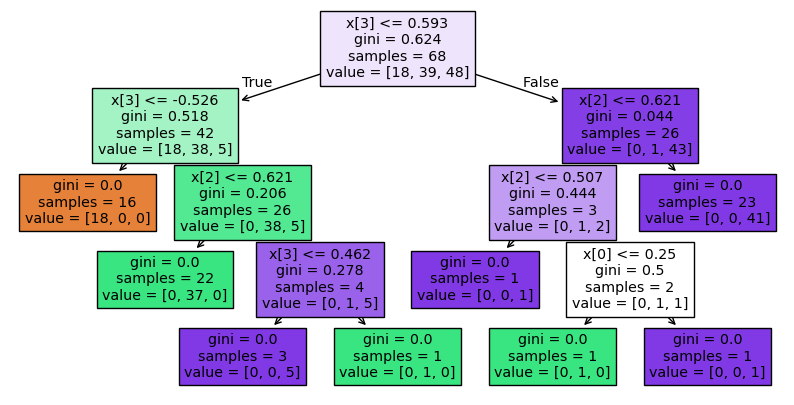

In [76]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,5))
plot_tree(model_grid.estimators_[0],filled=True)
plt.show()

**using randomizedsearchcv**

In [81]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [5,10,50,150,100, 200],
    'max_depth': [None, 5,10,15, 20],
    'min_samples_split': [1,2,3,4, 5],
    'min_samples_leaf': [1, 2,3],
    'bootstrap': [True, False]
}

In [82]:
random_search=RandomizedSearchCV(RandomForestClassifier(),param_grid)
random_search.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

RandomizedSearchCV(estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [1, 2, 3, 4, 5],
                                        'n_estimators': [5, 10, 50, 150, 100,
                                                         200]})

In [83]:
print("best_parameters",random_search.best_params_)
print("best_estimator",random_search.best_estimator_)

best_parameters {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}
best_estimator RandomForestClassifier(min_samples_split=5, n_estimators=200)


In [85]:
from sklearn.ensemble import RandomForestClassifier
random_grid=RandomForestClassifier(n_estimators=200,
                                  bootstrap=True,
                                  max_depth=None,
                                  min_samples_leaf=1,
                                  min_samples_split=5,
                                  random_state=42)
random_rf=model_grid.fit(x_train,y_train)
random_rf

RandomForestClassifier(min_samples_split=5, n_estimators=200, random_state=42)

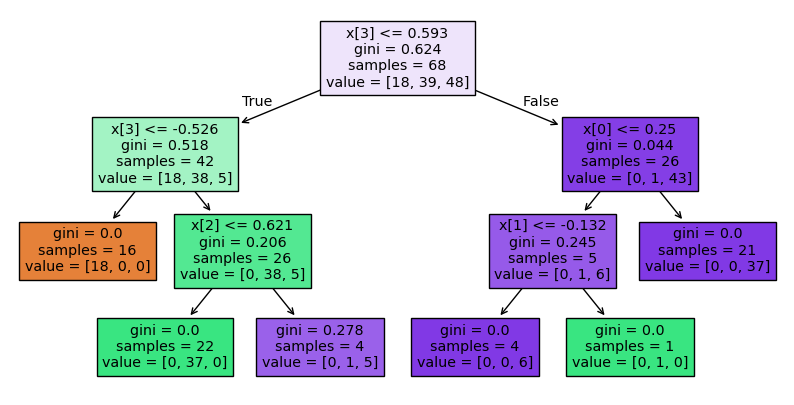

In [87]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,5))
plot_tree(random_rf.estimators_[0],filled=True)
plt.show()